In [10]:
# -*- coding: utf-8 -*-
from dreal import *
from Functions import *
import torch as th
import torch.nn.functional as F
import numpy as np
import timeit 
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}") ## device should be cuda 

Using device: cuda


In [11]:
class Learner(th.nn.Module):
    
    def __init__(self,n_input,n_hidden,n_output, controller=True, lqr=None):
        super(Learner, self).__init__()
        # th.manual_seed(2)
        self.layer1 = th.nn.Linear(n_input, n_hidden)
        self.activation1 = th.nn.Tanh()
        self.layer2 = th.nn.Linear(n_hidden,n_output)
        self.activation2 = th.nn.Tanh()

        self.controller = controller
        if self.controller:

            if lqr is None: raise ValueError("Input controller initialization")

            self.control = th.nn.Linear(n_input,1,bias=False)
            self.control.weight = th.nn.Parameter(lqr)

    def forward(self,x):
        h_1 = self.activation1(self.layer1(x))
        out = self.activation2(self.layer2(h_1))

        if self.controller:
            u = self.control(x)
            return out,u
        
        else:
            return out

## System

In [ ]:
# A1 = [[-1, -1], [5, -2]]
# A2 = [[-2, -4], [20, -2]]

# A1 = [[-1, -1], [1, -1]]
# A2 = [[-1, -10], [0.1, -1]]

A1 = [[-1, 0], [0, -1]]
A2 = [[-1, 0], [0, -1]]

B = [[1], [1]]



def f_auto(x):
    #Dynamics
    y = th.zeros(x.shape, device=x.device)
    
    A1 = th.tensor([[-1, -1], [5, -2]], dtype=th.float32, device=x.device)
    A2 = th.tensor([[-2, -4], [20, -2]], dtype=th.float32, device=x.device)

    
    for r in range(0,len(x)): 

        if x[r][1] <= 0: # x_1 <= 0
            # f = A1 @ x[r]
            y[r] = A1 @ x[r]
        else: # x_1 > 0
            # f = A2 @ x[r]
            y[r] = A2 @ x[r]

        # y.append(f) 

    # print(y)
    # y = th.stack(y).to(x.device)
    return y


def f_manu(x, u):
    #Dynamics
    y = th.zeros(x.shape, device=x.device)
    
    A1_ = th.tensor(A1, dtype=th.float32, device=x.device)
    A2_ = th.tensor(A2, dtype=th.float32, device=x.device)
    B_ = th.tensor(B, dtype=th.float32, device=x.device).squeeze()
    
    for r in range(0,len(x)): 

        if x[r][1] <= 0: # x_1 <= 0
            # f = A1 @ x[r]
            y[r] = A1_ @ x[r] + B_*u[r]
        else: # x_1 > 0
            # f = A2 @ x[r]
            y[r] = A2_ @ x[r] + B_*u[r]

        # y.append(f) 

    # print(y)
    # y = th.stack(y).to(x.device)
    return y



# lqr = th.tensor([[0.6797, 0.0700]], dtype=th.float32, device=device) 
lqr = th.tensor([[0.3660, 0.3660]], dtype=th.float32, device=device) 

## Options

In [13]:
'''
For learning 
'''
N = 500             # sample size
D_in = 2            # input dimension
H1 = 6              # hidden dimension
D_out = 1           # output dimension
# th.manual_seed(10)  
x = th.Tensor(N, D_in).uniform_(-6, 6).to(dtype=th.float32, device=device)
x_0 = th.zeros([1, 2], dtype=th.float32, device=device)

'''
For verifying 
'''
x1 = Variable("x1")
x2 = Variable("x2")
vars_ = [x1,x2]
switch_cond = x1 <= 0
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-2
epsilon = 0
# Checking candidate V within a ball around the origin (ball_lb ≤ sqrt(∑xᵢ²) ≤ ball_ub)
ball_lb = 0.5
ball_ub = 6

In [14]:
def resample_location(x, lb=-6, ub=6, n=100):

    new_x = th.Tensor(n, D_in).uniform_(lb, ub).to(device=x.device, dtype=th.float32)

    if x.shape[0] <= 500:
        x = torch.cat((x, new_x), 0)
    
    else:
        idx = torch.randperm(x.shape[0], device=x.device)[:n]
        x[idx] = new_x


    return x

## Learning and Falsification


In [ ]:
out_iters = 0
valid = False
TRIES = 4
MAX_ITERS = 2000

lyap_risks = np.zeros((TRIES, MAX_ITERS))

while out_iters < TRIES and not valid: 
    start = timeit.default_timer()
    # lqr = th.tensor([[-23.58639732,  -5.31421063]], dtype=th.float32)    # lqr solution
    
    model = Learner(D_in,H1, D_out, controller=True, lqr=lqr).to(device)
    L = []
    i = 0 
    t = 0
    
    # learning_rate = 0.01
    learning_rate = 0.01
    # optimizer = th.optim.Adam(model.parameters(), lr=learning_rate)
    optimizer = torch.optim.RMSprop(model.parameters(), lr=0.01, alpha=0.99, eps=1e-8, weight_decay=1e-4)

    while i < MAX_ITERS and not valid: 
        V_candidate, u = model(x)
        X0, u0 = model(x_0)
        f = f_manu(x, u)

        # Compute lie derivative of V : L_V = ∑∂V/∂xᵢ*fᵢ
        L_V = th.diagonal(th.mm(th.mm(th.mm(dtanh(V_candidate),model.layer2.weight)\
                            *dtanh(th.tanh(th.mm(x,model.layer1.weight.t())+model.layer1.bias)),model.layer1.weight),f.t()),0)
        
        # With tuning term 
        # Circle_Tuning = Tune(x)
        # Lyapunov_risk = (F.relu(-V_candidate)+ 1.5*F.relu(L_V+0.5)).mean()\
        #             +2.2*((Circle_Tuning-6*V_candidate).pow(2)).mean()+(X0).pow(2) 

        # Without tuning term
        Lyapunov_risk = (F.relu(-V_candidate)+ F.relu(L_V+0.5)).mean()+ (X0).pow(2)
        # Lyapunov_risk = (F.relu(-V_candidate)+ F.relu(L_V+0.5)).mean()+(X0).pow(2)

        # Lyapunov_risk = (F.relu(-V_candidate)).mean() + (1.5*F.relu(L_V+0.5)).mean()+ 1.2*(X0).pow(2)
        
        
        print(i, "Lyapunov Risk=",Lyapunov_risk.item()) 
        L.append(Lyapunov_risk.item())
        lyap_risks[out_iters, i] = Lyapunov_risk.item()
        optimizer.zero_grad()
        Lyapunov_risk.backward()
        optimizer.step() 

        w1 = model.layer1.weight.data.cpu().numpy()
        w2 = model.layer2.weight.data.cpu().numpy()
        b1 = model.layer1.bias.data.cpu().numpy()
        b2 = model.layer2.bias.data.cpu().numpy()
        q = model.control.weight.data.cpu().numpy()

        # Falsification
        if i % 10 == 0:
            # u_NN = (q.item(0)*x1 + q.item(1)*x2) 
            # f = [ x2,
            #      (m*G*l*sin(x1) + u_NN - b*x2) /(m*l**2)]
            
            f1 = np.dot(A1-B@q, vars_)
            f2 = np.dot(A2-B@q, vars_)
            
            # Candidate V
            z1 = np.dot(vars_,w1.T)+b1

            a1 = []
            for j in range(0,len(z1)):
                a1.append(tanh(z1[j]))
            z2 = np.dot(a1,w2.T)+b2
            V_learn = tanh(z2.item(0))

            print('===========Verifying==========')        
            start_ = timeit.default_timer() 
            # result = CheckLyapunov(vars_, f, V_learn, ball_lb, ball_ub, config,epsilon)
            # 'LP' for relaxing Lyapunov function 
            # 'LD' for relaxing Lie Derivatie
            result = CheckLyapunovRelaxed(vars_, f1, f2, switch_cond, V_learn, ball_lb, ball_ub, config,epsilon)
            stop_ = timeit.default_timer() 

            if (result): 
                print("Not a Lyapunov function. Found counterexample: ")
                print(result)
                # x = resample_location(x, n=75)
                x = AddCounterexamples(x,result,10, replace=False).to(th.float32)

                if False:
                    for _ in range(3):
                        ces = SampleCounterexamples(result, 10, x.device).to(th.float32)
                        
                        V_candidate, u = model(ces)
                        X0, u0 = model(x_0)
                        f = f_manu(ces, u)

                        # Compute lie derivative of V : L_V = ∑∂V/∂xᵢ*fᵢ
                        L_V = th.diagonal(th.mm(th.mm(th.mm(dtanh(V_candidate),model.layer2.weight)\
                                            *dtanh(th.tanh(th.mm(ces,model.layer1.weight.t())+model.layer1.bias)),model.layer1.weight),f.t()),0)
                        
                        Lyapunov_risk = (F.relu(-V_candidate)+ 2*F.relu(L_V+0.5)).mean()+ 1.2*(X0).pow(2)

                        optimizer.zero_grad()
                        Lyapunov_risk.backward()
                        optimizer.step() 

                        print("CE Lyapunov Risk=",Lyapunov_risk.item()) 

            else:  
                valid = True
                print("Satisfy conditions!!")
                print(V_learn, " is a Lyapunov function.")
            t += (stop_ - start_)
            print('==============================') 
        i += 1

    stop = timeit.default_timer()


    # np.savetxt("w1.txt", model.layer1.weight.data, fmt="%s")
    # np.savetxt("w2.txt", model.layer2.weight.data, fmt="%s")
    # np.savetxt("b1.txt", model.layer1.bias.data, fmt="%s")
    # np.savetxt("b2.txt", model.layer2.bias.data, fmt="%s")
    # np.savetxt("q.txt", model.control.weight.data, fmt="%s")

    print('\n')
    print("Total time: ", stop - start)
    print("Verified time: ", t)
    print(f"Lyapunov Function found: {valid}")
    
    out_iters+=1


0 Lyapunov Risk= 1.2356151342391968
===========Verifying==========
Not a Lyapunov function. Found counterexample: 
x1 : [-2.4516170616880197, -2.44161706168802]
x2 : [-3.6931029730885445, -3.6831029730885447]
1 Lyapunov Risk= 1.0613644123077393
2 Lyapunov Risk= 0.9698061943054199
3 Lyapunov Risk= 0.9085686802864075
4 Lyapunov Risk= 0.8811954259872437
5 Lyapunov Risk= 0.8666667938232422
6 Lyapunov Risk= 0.8048360347747803
7 Lyapunov Risk= 0.7888213992118835
8 Lyapunov Risk= 0.7544427514076233
9 Lyapunov Risk= 0.7251463532447815
10 Lyapunov Risk= 0.6808551549911499
===========Verifying==========
Not a Lyapunov function. Found counterexample: 
x1 : [4.123903240560618, 4.1339032405606178]
x2 : [-3.2120003233892502, -3.2020003233892504]
11 Lyapunov Risk= 0.6372688412666321
12 Lyapunov Risk= 0.5700964331626892
13 Lyapunov Risk= 0.5004948377609253
14 Lyapunov Risk= 0.44930556416511536
15 Lyapunov Risk= 0.4223610758781433
16 Lyapunov Risk= 0.3804894685745239
17 Lyapunov Risk= 0.342555701732635

In [16]:
# evaluate counter example

ce = np.array([result[0].mid(), result[1].mid()])
# ce = np.array([result[0].ub(), result[1].ub()])
# ce = np.array([result[0].lb(), result[1].lb()])

if ce[0] <= 0:
    f = np.dot(A1-B@q, ce)
else:
    f = np.dot(A2-B@q, ce)


# Lyapunov function
lf = np.tanh(np.dot(np.tanh(np.dot(ce, w1.T) + b1), w2.T) + b2)

# Lie Derivative
ld = np.matmul( np.matmul( np.matmul(dtanh(lf), w2) * dtanh(np.tanh(np.matmul(ce,w1.T)+b1)),w1 ),f.T )

# Origin value 
v0 = np.tanh(np.dot(np.tanh(np.dot(np.zeros(2), w1.T) + b1), w2.T) + b2)

print("Constraints: V(.) > 0, dV(.) < 0, V(0) = 0")
print(f'Counter Example: V(x) = {lf.item():.2f}, dV(x) = {ld.item():.2f}, v0 = {v0.item():.2f}')


Constraints: V(.) > 0, dV(.) < 0, V(0) = 0
Counter Example: V(x) = 0.67, dV(x) = 1.17, v0 = -0.01


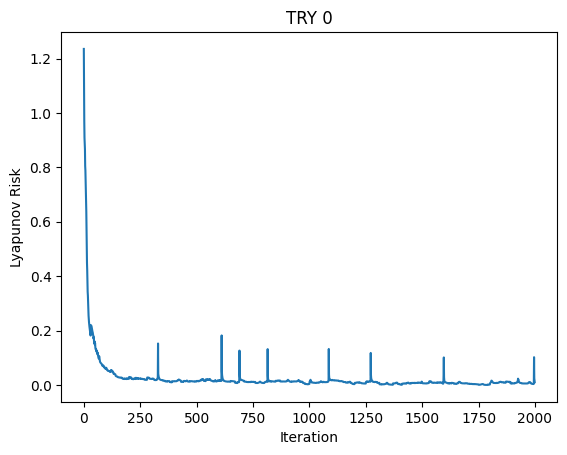

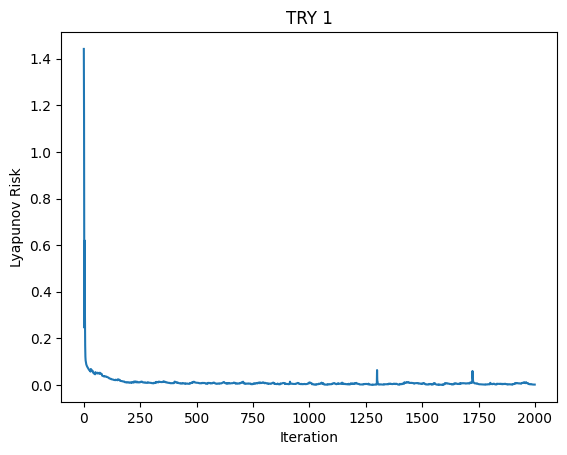

In [17]:
for i in range(out_iters):

    plt.figure()
    plt.plot(lyap_risks[i, :])
    plt.title(f'TRY {i}')
    plt.xlabel('Iteration')
    plt.ylabel('Lyapunov Risk')
    plt.show()
